# Loan Default Risk Prediction using Machine Learning

## Business Understanding
Financial institutions and lending companies face significant financial risk when issuing loans to applicants who may ultimately default. Accurately predicting whether a borrower is likely to default allows lenders to mitigate risk, optimize interest rates, and make data-driven approval decisions.

The objective of this project is to build a comprehensive machine learning pipeline using real-world loan data. We will start with a robust Logistic Regression baseline, apply advanced data preprocessing and feature engineering, and ultimately benchmark our linear model against powerful ensemble algorithms (Decision Trees, Random Forests, and XGBoost).

### Project Workflow
- Environment Setup & Data Ingestion
- Data Quality Assessment & Comprehensive Cleaning (Missing values, duplicates, invalid entries)
- Outlier Treatment (IQR Capping for continuous variables)
- Exploratory Data Analysis (EDA - Distributions & Correlation Matrix)
- Data Preprocessing & Feature Engineering (Encoding & Standard Scaling)
- Baseline Model Development & Evaluation
- Hyperparameter Tuning & Regularization Analysis
- Multi-Model Benchmarking (Logistic Regression vs. Trees vs. Ensemble)
- Custom Prediction Function & Model Serialization

# Environment Setup & Data Ingestion
Importing core data science libraries for manipulation, visualization, and machine learning, followed by loading the real-world dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load Dataset (Ensure 'loan_default.csv' is placed in ../data/raw/)
df = pd.read_csv('../data/raw/loan_default.csv')

# Define Target Column explicitly based on the dataset structure
# (Commonly named 'default' or 'loan_default' in financial datasets)
TARGET_COL = 'default' if 'default' in df.columns else df.columns[-1]

print(f"Dataset Shape: {df.shape}")
display(df.head())
display(df.info())

Dataset Shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

None

**Phase Summary:**
Libraries successfully imported and dataset loaded into memory. The target column was explicitly identified to prevent structural misalignment during modeling.
___

# Data Quality Assessment & Comprehensive Cleaning

In this phase, we drop the unique identifier (`LoanID`), inspect the target variable (`Default`) to verify class distribution, handle missing values and duplicates, and apply IQR capping exclusively to continuous financial variables (such as Income, LoanAmount, CreditScore, InterestRate, and DTIRatio) while protecting discrete and binary features.

In [2]:
# 1. Define Target and Identifier
TARGET_COL = 'Default'
ID_COL = 'LoanID'

# Drop ID column if present
if ID_COL in df.columns:
    df.drop(columns=[ID_COL], inplace=True)

# 2. Verify Target Distribution
print("--- Target Distribution (Default) ---")
print(df[TARGET_COL].value_counts())
print("\nPercentage Distribution:")
print(df[TARGET_COL].value_counts(normalize=True) * 100)

# 3. Handle Missing Values and Duplicates
missing_before = df.isnull().sum().sum()
duplicates_count = df.duplicated().sum()

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# 4. Outlier Treatment (IQR Capping) - Strictly for Continuous Numerical Columns
continuous_cols = ['Income', 'LoanAmount', 'CreditScore', 'InterestRate', 'DTIRatio', 'MonthsEmployed']
continuous_cols = [col for col in continuous_cols if col in df.columns]

capped_info = {}
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers_count = outliers_mask.sum()
    
    if outliers_count > 0:
        capped_info[col] = outliers_count
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print(f"\nMissing Values Handled: {missing_before}")
print(f"Duplicates Removed: {duplicates_count}")
print("\n--- Outliers Capped Per Continuous Column ---")
for col, count in capped_info.items():
    print(f"  -> {col}: {count} outliers capped")

print(f"\nCleaned Dataset Shape: {df.shape}")

--- Target Distribution (Default) ---
Default
0    225694
1     29653
Name: count, dtype: int64

Percentage Distribution:
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

Missing Values Handled: 0
Duplicates Removed: 0

--- Outliers Capped Per Continuous Column ---

Cleaned Dataset Shape: (255347, 17)


___
# Exploratory Data Analysis (EDA)

Visualizing the target distribution to check for class balance, plotting continuous feature distributions, and generating a correlation matrix to analyze linear relationships with the loan default target.

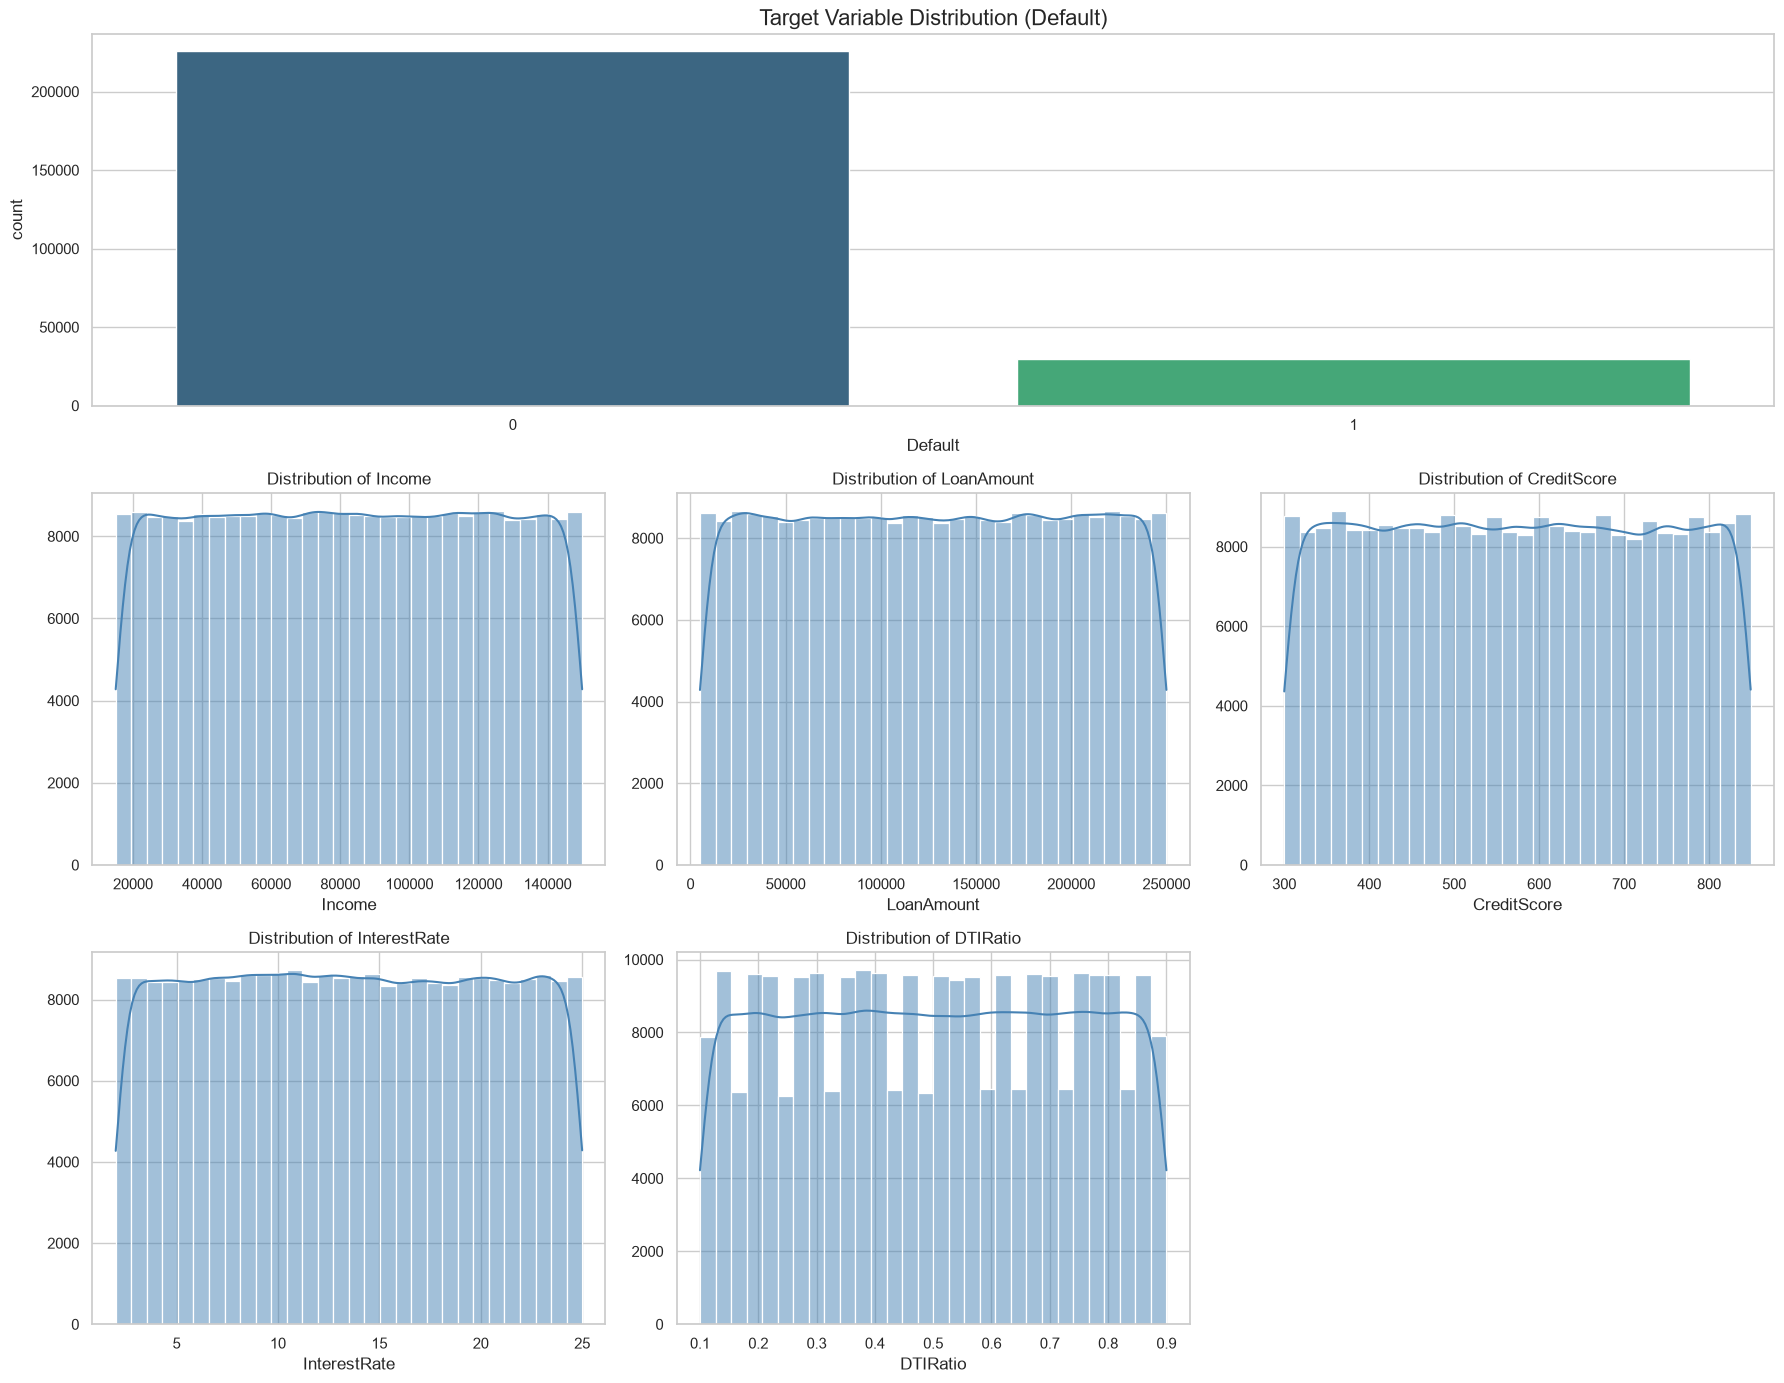

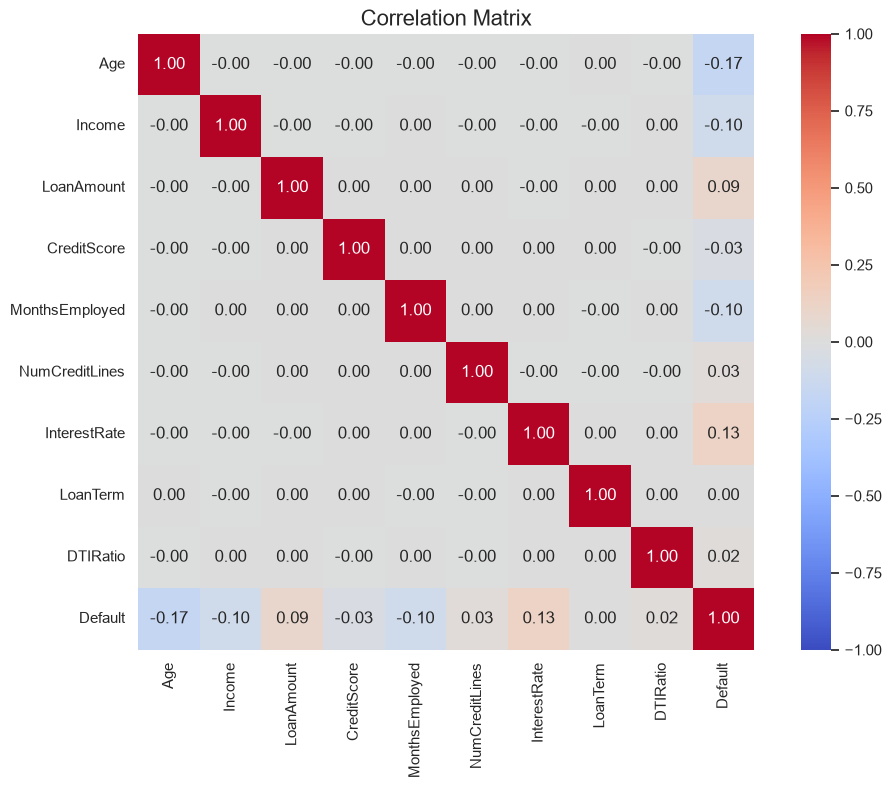

In [3]:
# Setup EDA Visualization
fig = plt.figure(figsize=(18, 14))

# 1. Target Distribution
ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=3)
sns.countplot(data=df, x=TARGET_COL, palette='viridis', ax=ax1)
ax1.set_title("Target Variable Distribution (Default)", fontsize=16)

# 2. Key Continuous Distributions
key_num_cols = ['Income', 'LoanAmount', 'CreditScore', 'InterestRate', 'DTIRatio']
for i, col in enumerate(key_num_cols):
    ax = plt.subplot2grid((3, 3), (1 + i // 3, i % 3))
    sns.histplot(df[col], kde=True, bins=30, color='steelblue', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

# 3. Correlation Matrix for Numerical Features
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

# Data Preprocessing & Feature Engineering

Preparing the dataset strictly for Logistic Regression. Logistic Regression relies on gradient descent optimization and assumes that all features contribute equally to distance and weight calculations. 

In this phase, we encode categorical features into a machine-readable format using One-Hot Encoding and apply Standard Scaling (`StandardScaler`) to all continuous numerical features. Standardizing features is essential to ensure that regularization penalties (L1 and L2) are applied uniformly without being biased by the scale of individual variables.

In [4]:
# 1. One-Hot Encoding for Categorical Features
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 2. Split Features (X) and Target (y)
X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[TARGET_COL]

# 3. Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Preprocessing completed successfully!")
print(f"Features Shape (X_scaled): {X_scaled.shape}")
print(f"Target Shape (y): {y.shape}")
display(X_scaled.head())

Preprocessing completed successfully!
Features Shape (X_scaled): (255347, 24)
Target Shape (y): (255347,)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education_High School,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
0,0.833990,0.089693,-1.086833,-0.341492,0.590533,1.341937,0.261771,-0.001526,-0.260753,-0.577750,...,-0.577273,-0.708268,-0.706461,0.999973,0.999464,-0.501398,-0.499606,-0.501325,2.003812,0.999785
1,1.701221,-0.823021,-0.044309,-0.731666,-1.285731,-1.343791,-1.308350,1.412793,0.778585,-0.577750,...,-0.577273,1.411895,-0.706461,-1.000027,-1.000537,-0.501398,-0.499606,-0.501325,2.003812,0.999785
2,0.166888,0.043854,0.022715,-0.775718,-0.968209,0.446694,1.156831,-0.708685,-0.823728,-0.577750,...,1.732281,-0.708268,-0.706461,0.999973,0.999464,-0.501398,-0.499606,-0.501325,-0.499049,-1.000215
3,-0.767053,-1.303452,-1.168538,1.061875,-1.718715,0.446694,-0.967805,-0.708685,-1.170174,1.730853,...,-0.577273,1.411895,-0.706461,-1.000027,-1.000537,1.994422,-0.499606,-0.501325,-0.499049,-1.000215
4,1.100830,-1.592855,-1.671921,0.369631,-1.487790,1.341937,-1.052188,0.705634,0.995114,-0.577750,...,1.732281,-0.708268,-0.706461,-1.000027,0.999464,-0.501398,-0.499606,-0.501325,-0.499049,-1.000215


# Baseline Model Development

Establishing a baseline model is a critical milestone in any machine learning pipeline. It provides a reference performance metric to evaluate whether subsequent advanced algorithms or hyperparameter tuning actually add value. We will train a standard Logistic Regression model with default parameters.

Training Set Shape: (204277, 24)
Testing Set Shape: (51070, 24)

--- Baseline Model Evaluation ---
Accuracy Score: 0.8853

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070



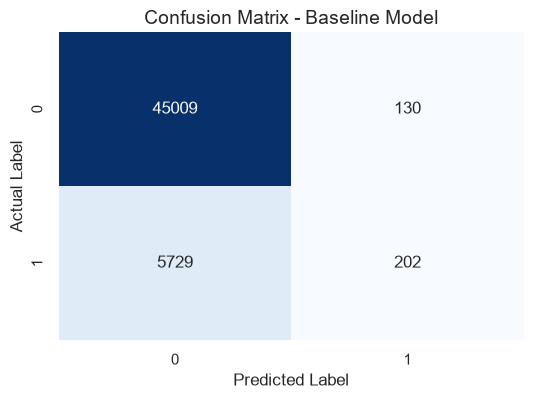

In [5]:
# 1. Train-Test Split (Stratified to maintain class balance given the ~11% default rate)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

# 2. Train Baseline Logistic Regression Model
base_model = LogisticRegression(random_state=42, max_iter=1000)
base_model.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_base = base_model.predict(X_test)

print("\n--- Baseline Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_base):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

# 4. Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Baseline Model", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**Phase Summary:**
Categorical variables were successfully encoded, and features were standardized. The model was trained using stratified splitting to preserve class distributions, establishing a solid performance baseline for future comparison.

___
# Hyperparameter Tuning

The baseline model struggled to identify the minority class (loan defaults) due to class imbalance (~11% positive class). In this phase, we use `GridSearchCV` to optimize the inverse regularization strength parameter (`C`) and the solver, while explicitly incorporating `class_weight='balanced'` to penalize misclassifications of the minority class and improve Recall.

In [6]:

# Setup GridSearchCV with class weight balancing
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    param_grid=param_grid,
    scoring='f1', # Optimizing for F1-score to balance Precision and Recall
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate Tuned Model
y_pred_tuned = best_model.predict(X_test)
print("\n--- Tuned Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))


Best Parameters: {'C': 0.001, 'solver': 'lbfgs'}

--- Tuned Model Evaluation ---
Accuracy Score: 0.6766

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



# Polynomial Features Engineering

Logistic Regression is inherently a linear classifier. To test if we can capture non-linear relationships and feature interactions (e.g., how Income combined with Debt-to-Income ratio affects risk), we generate second-degree interaction features using `PolynomialFeatures` and evaluate the impact on model performance.

In [7]:
# Generate interaction-only polynomial features to prevent explosive dimensionality
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Original Feature Count: {X_train.shape[1]}")
print(f"Polynomial Feature Count: {X_train_poly.shape[1]}")

# Train Logistic Regression on Polynomial Features
poly_model = LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced', C=0.1)
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

print("\n--- Polynomial Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_poly):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_poly))

Original Feature Count: 24
Polynomial Feature Count: 300

--- Polynomial Model Evaluation ---
Accuracy Score: 0.6813

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.68      0.79     45139
           1       0.22      0.70      0.34      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.74     51070



# Regularization Analysis (L1 vs. L2)

Regularization adds a penalty to the loss function to prevent overfitting and control model complexity. 
- **L2 (Ridge):** Shrinks coefficients smoothly.
- **L1 (Lasso):** Can drive coefficients entirely to zero, performing automatic feature selection.

Here, we compare L1 and L2 penalties to see which regularization strategy yields better generalization for financial risk classification.

In [8]:
# Train L1 (Lasso) Regularized Logistic Regression
l1_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, class_weight='balanced', max_iter=1000)
l1_model.fit(X_train, y_train)
y_pred_l1 = l1_model.predict(X_test)

# Train L2 (Ridge) Regularized Logistic Regression
l2_model = LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, random_state=42, class_weight='balanced', max_iter=1000)
l2_model.fit(X_train, y_train)
y_pred_l2 = l2_model.predict(X_test)

print("--- L1 (Lasso) Regularization Report ---")
print(classification_report(y_test, y_pred_l1))

print("\n--- L2 (Ridge) Regularization Report ---")
print(classification_report(y_test, y_pred_l2))

--- L1 (Lasso) Regularization Report ---
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070


--- L2 (Ridge) Regularization Report ---
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



# Decision Boundary Visualization

Logistic Regression creates a linear decision boundary to separate classes. To visualize how our model separates low-risk customers from high-risk defaulters, we apply Principal Component Analysis (PCA) to reduce our feature space down to 2 dimensions and plot the decision boundary.

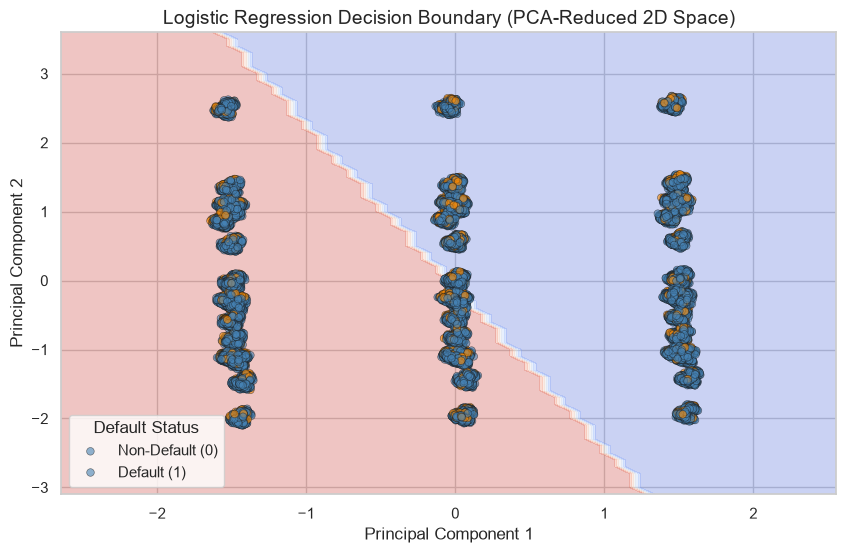

In [9]:
# Apply PCA to reduce features to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train a 2D Logistic Regression model for boundary plotting
clf_2d = LogisticRegression(random_state=42, class_weight='balanced', C=0.1)
clf_2d.fit(X_train_pca, y_train)

# Plotting the Decision Boundary
plt.figure(figsize=(10, 6))
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_test, palette=['steelblue', 'darkorange'], alpha=0.6, edgecolor='k', s=30)
plt.title("Logistic Regression Decision Boundary (PCA-Reduced 2D Space)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Default Status", labels=['Non-Default (0)', 'Default (1)'])
plt.show()

# Multi-Model Comparison & Benchmarking

While Logistic Regression provides high interpretability, complex financial relationships often benefit from non-linear and ensemble models. 

In this phase, we benchmark our optimized Logistic Regression against three powerful algorithms:
1. **Decision Tree Classifier** (Captures hierarchical decision rules)
2. **Random Forest Classifier** (Bagging ensemble to reduce overfitting)
3. **XGBoost Classifier** (Advanced gradient boosting designed for structured tabular data)

We will evaluate all models using classification reports to determine the best performer.

In [12]:
# Calculate scale_pos_weight for XGBoost to handle class imbalance natively
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

# Define models dictionary
models = {
    "Logistic Regression (Tuned)": LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, random_state=42, class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, scale_pos_weight=scale_weight, n_estimators=100, max_depth=6, n_jobs=-1, eval_metric='logloss')
}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n==============================================")
    print(f"Training and Evaluating: {name}")
    print(f"==============================================")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))


Training and Evaluating: Logistic Regression (Tuned)
Accuracy Score: 0.6765

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070


Training and Evaluating: Decision Tree
Accuracy Score: 0.6630

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.66      0.78     45139
           1       0.20      0.65      0.31      5931

    accuracy                           0.66     51070
   macro avg       0.57      0.66      0.54     51070
weighted avg       0.85      0.66      0.72     51070


Training and Evaluating: Random Forest
Accuracy Score: 0.8802

Classification Report:
              precision    recall  f1-score   support

           0    

# Baseline Dummy Comparison

To mathematically prove that our machine learning models are actually learning from the financial data and not just guessing the majority class, we compare our best model against a `DummyClassifier`. 
The DummyClassifier strictly predicts the most frequent class (Non-Default).

In [13]:
from sklearn.dummy import DummyClassifier

# Train Dummy Classifier
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

print("--- Dummy Classifier Report ---")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

--- Dummy Classifier Report ---
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     45139
           1       0.00      0.00      0.00      5931

    accuracy                           0.88     51070
   macro avg       0.44      0.50      0.47     51070
weighted avg       0.78      0.88      0.83     51070



# Custom Prediction Function

To make the model usable in production (e.g., Streamlit), we create a robust inference function. This function takes raw customer data, handles missing dummy variables dynamically, scales the input, and returns the predicted class along with the probability of default.

In [14]:
def predict_loan_default(model, scaler, feature_columns, age, income, loan_amount, credit_score, 
                         months_employed, num_credit_lines, interest_rate, loan_term, dti_ratio,
                         education='Bachelor\'s', employment_type='Full-time', 
                         marital_status='Single', has_mortgage='No', 
                         has_dependents='No', loan_purpose='Other', has_cosigner='No'):
    """
    Predicts the likelihood of loan default for a single applicant.
    """
    # 1. Create a DataFrame from the input
    input_data = pd.DataFrame([{
        'Age': age, 'Income': income, 'LoanAmount': loan_amount,
        'CreditScore': credit_score, 'MonthsEmployed': months_employed,
        'NumCreditLines': num_credit_lines, 'InterestRate': interest_rate,
        'LoanTerm': loan_term, 'DTIRatio': dti_ratio,
        'Education': education, 'EmploymentType': employment_type,
        'MaritalStatus': marital_status, 'HasMortgage': has_mortgage,
        'HasDependents': has_dependents, 'LoanPurpose': loan_purpose,
        'HasCoSigner': has_cosigner
    }])

    # 2. One-Hot Encode the input
    input_encoded = pd.get_dummies(input_data)

    # 3. Align columns with training data (fill missing dummy columns with 0)
    input_aligned = input_encoded.reindex(columns=feature_columns, fill_value=0)

    # 4. Scale features
    input_scaled = scaler.transform(input_aligned)

    # 5. Predict
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    result = "High Risk (Default)" if prediction == 1 else "Low Risk (Approved)"
    
    return result, round(probability * 100, 2)


# Let's test the function using our tuned Logistic Regression model!
# We extract the logistic regression model trained in Phase 11
trained_lr_model = models["Logistic Regression (Tuned)"]

# Test Case 1: High-Risk Profile (Low Income, High Loan, Low Credit Score, High DTI)
status, prob = predict_loan_default(
    model=trained_lr_model, 
    scaler=scaler, 
    feature_columns=X.columns,
    age=25, income=35000, loan_amount=150000, credit_score=450, 
    months_employed=6, num_credit_lines=8, interest_rate=18.5, 
    loan_term=60, dti_ratio=0.85
)

print(f"Test Case 1 Output: {status} with a default probability of {prob}%")

Test Case 1 Output: High Risk (Default) with a default probability of 93.31%


In [15]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Export assets
joblib.dump(trained_lr_model, '../models/logistic_regression_model.joblib')
joblib.dump(scaler, '../models/standard_scaler.joblib')
joblib.dump(X.columns.tolist(), '../models/feature_columns.joblib')

print("Model, Scaler, and Feature Columns have been successfully saved to /models/")

Model, Scaler, and Feature Columns have been successfully saved to /models/
